# Machine Learning Zoomcamp, cohort 2024
# HW5 / Arcangela Arnone Cohen

## Question

* Install Pipenv
* What's the version of pipenv you installed?
* Use `--version` to find out

In [45]:
!pipenv --version

pipenv, version 2024.3.0


In [ ]:
# Instruction executed after completed question 4

In [5]:
import sklearn
print('The scikit-learn version is:{}.'.format(sklearn.__version__))

The scikit-learn version is:1.4.2.


In [ ]:
# this scikit version is local in my machine.  More laater I have updated it (for question 4)

## Question 2

* Use Pipenv to install Scikit-Learn version 1.5.2
* What's the first hash for scikit-learn you get in Pipfile.lock?

> **Note**: you should create an empty folder for homework
and do it there. 


"sha256:03b6158efa3faaf1feea3faa884c840ebd61b6484167c711548fce208ea09445"

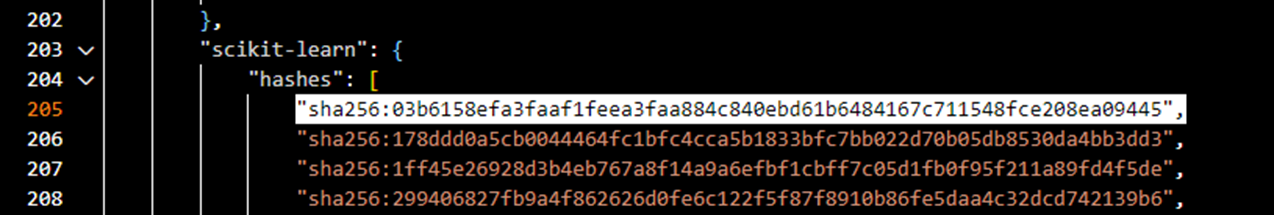!

## Models

We've prepared a dictionary vectorizer and a model.

They were trained (roughly) using this code:

```python
features = ['job', 'duration', 'poutcome']
dicts = df[features].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X = dv.fit_transform(dicts)

model = LogisticRegression().fit(X, y)
```

> **Note**: You don't need to train the model. This code is just for your reference.

And then saved with Pickle. Download them:

* [DictVectorizer](https://github.com/DataTalksClub/machine-learning-zoomcamp/tree/master/cohorts/2024/05-deployment/homework/dv.bin?raw=true)
* [LogisticRegression](https://github.com/DataTalksClub/machine-learning-zoomcamp/tree/master/cohorts/2024/05-deployment/homework/model1.bin?raw=true)

With `wget`:

```bash
PREFIX=https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/master/cohorts/2024/05-deployment/homework
wget $PREFIX/model1.bin
wget $PREFIX/dv.bin``


In [7]:
import pickle
import requests

In [9]:
PREFIX = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/master/cohorts/2024/05-deployment/homework"
files_to_download = ["model1.bin", "dv.bin"]

for file in files_to_download:
    url = f"{PREFIX}/{file}"
    response = requests.get(url)

    if response.status_code == 200:
        with open(file, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded: {file}")
    else:
        print(f"Failed to download: {url}")

Downloaded: model1.bin
Downloaded: dv.bin


## Question 3

Let's use these models!

* Write a script for loading these models with pickle
* Score this client:

```json
{"job": "management", "duration": 400, "poutcome": "success"}
```

What's the probability that this client will get a subscription? 

* 0.359
* 0.559
* 0.759
* 0.959

If you're getting errors when unpickling the files, check their checksum:

```bash
$ md5sum model1.bin dv.bin
3d8bb28974e55edefa000fe38fd3ed12  model1.bin
7d37616e00aa80f2152b8b0511fc2dff  dv.bin``


In [ ]:
# Write a script for loading these models with pickle

In [11]:
with open("model1.bin", "rb") as f_in:
    model = pickle.load(f_in)

with open("dv.bin", "rb") as f_in:
    dv = pickle.load(f_in)

C:\Users\arcangelaac\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\arcangelaac\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DictVectorizer from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
client = {"job": "management", "duration": 400, "poutcome": "success"}
X = dv.transform(client)
y_pred = model.predict_proba(X)[0, 1]

In [ ]:
# the dictionary vectorizer with the  transform instruction can tak our dictionary and can turn this in something  
# that we can put in our machine learning model, in terms of zeros and ones

In [15]:
print('input:', client)
print('Q3 answer, output:', y_pred)

input: {'job': 'management', 'duration': 400, 'poutcome': 'success'}
Q3 answer, output: 0.9085008884049968


In [17]:
dv

DictVectorizer(sparse=False)

In [19]:
model

LogisticRegression(max_iter=250, multi_class='deprecated')

In [ ]:
# the client used is a Dictionary object.  this question shows how load the model and how to apply it to one customer
# and the how the customer was scored with the probability of 1, the following line show the array

In [21]:
model.predict_proba(X)

array([[0.09149911, 0.90850089]])

## Question 4

Now let's serve this model as a web service

* Install Flask and gunicorn (or waitress, if you're on Windows)
* Write Flask code for serving the model
* Now score this client using `requests`:

```python
url = "YOUR_URL"
client = {"job": "student", "duration": 280, "poutcome": "failure"}
requests.post(url, json=client).json()
```

What's the probability that this client will get a subscription?

* 0.335
* 0.535
* 0.735
* 0.935

In [23]:
!pip install Flask
!pip install waitress

In [43]:
import requests

url = "http://127.0.0.1:9696/predict"  
client_data = {"job": "student", "duration": 280, "poutcome": "failure"}

response = requests.post(url, json=client_data)

if response.status_code == 200:
    data = response.json()
    suscription_probability = data.get("suscription_probability")
    print(f"Suscription Probability: {suscription_probability}")
else:
    print("Failed to make the prediction.")

Suscription Probability: 0.33480703475511053


In [ ]:
# My answer is 0.33480703475511053

## Docker

Install [Docker](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/05-deployment/06-docker.md). 
We will use it for the next two questions.

For these questions, we prepared a base image: `svizor/zoomcamp-model:3.11.5-slim`. 
You'll need to use it (see Question 5 for an example).

This image is based on `python:3.11.5-slim` and has a logistic regression model 
(a different one) as well a dictionary vectorizer inside. 

This is how the Dockerfile for this image looks like:

```docker 
FROM python:3.11.5-slim
WORKDIR /app
COPY ["model2.bin", "dv.bin", "./"]
```

We already built it and then pushed it to [`svizor/zoomcamp-model:3.11.5-slim`](https://hub.docker.com/r/svizor/zoomcamp-model).

> **Note**: You don't need to build this docker image, it's just for your reference.

In [ ]:
# worked in the following questions

## Question 5

Download the base image `svizor/zoomcamp-model:3.11.5-slim`. You can easily make it by using [docker pull](https://docs.docker.com/engine/reference/commandline/pull/) command.

So what's the size of this base image?

* 45 MB
* 130 MB
* 245 MB
* 330 MB

You can get this information when running `docker images` - it'll be in the "SIZE" column.

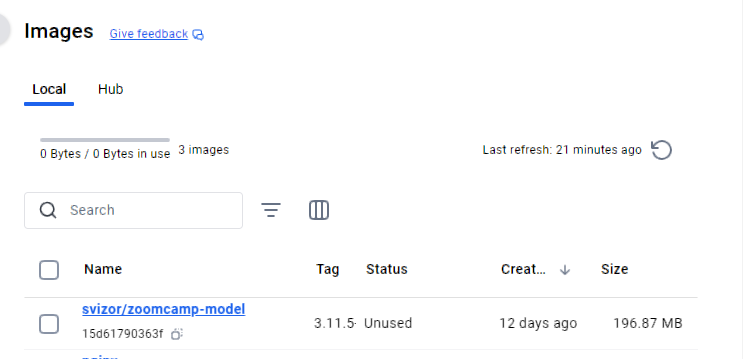

## Dockerfile

Now create your own Dockerfile based on the image we prepared.

It should start like that:

```docker
FROM svizor/zoomcamp-model:3.11.5-slim
# add your stuff here
```

Now complete it:

* Install all the dependencies form the Pipenv file
* Copy your Flask script
* Run it with Gunicorn 

After that, you can build your docker image.

## Question 6

Let's run your docker container!

After running it, score this client once again:

```python
url = "YOUR_URL"
client = {"job": "management", "duration": 400, "poutcome": "success"}
requests.post(url, json=client).json()
```

What's the probability that this client will get a subscription now?

* 0.287
* 0.530
* 0.757
* 0.960


## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2024/homework/hw05
* If your answer doesn't match options exactly, select the closest one

In [ ]:
# not finished

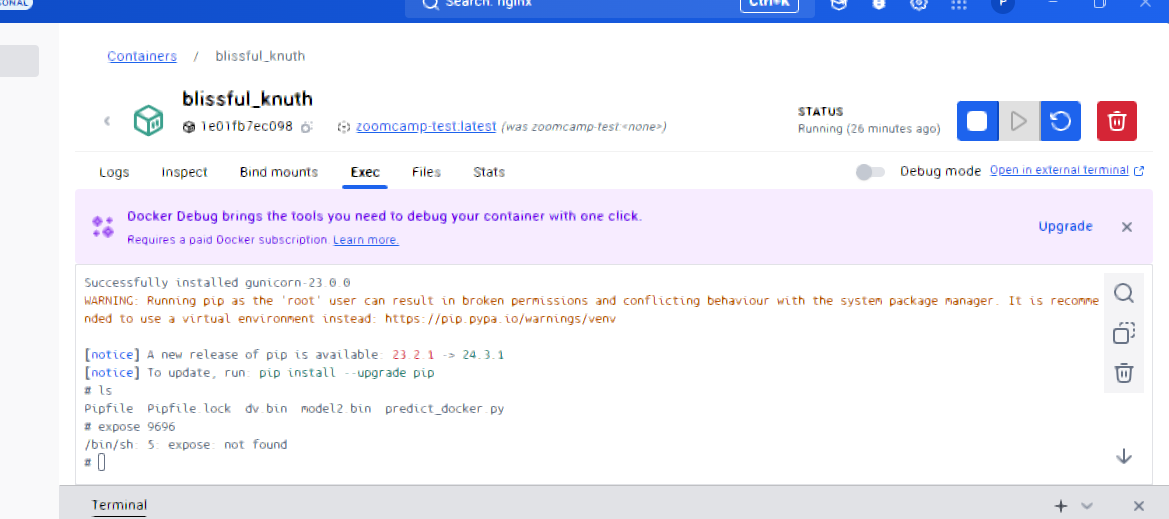

In [12]:
import requests 
url = "http://0.0.0.0:9696/suscription"
client = {"job": "management", "duration": 400, "poutcome": "success"}
requests.post(url, json=client).json()

ConnectionError: HTTPConnectionPool(host='0.0.0.0', port=9696): Max retries exceeded with url: /prediction (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x00000232B07A07D0>: Failed to establish a new connection: [WinError 10049] La dirección solicitada no es válida en este contexto'))

# end